# 03: Python-based Preprocessing Routine Reproducibility

## Dataset
- [GSE223065](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE223065)

---
## 0. Execution Environment Summary

In [1]:
%%bash
bash .rep_exe_env_short.sh

=== Execution Start ===


Timestamp (UTC): 2026-09-29T19:26:09Z


Hostname:        hww04


OS:              Red Hat Enterprise Linux 8.8 (Ootpa)


---
## 1. Data Download

In [2]:
%%bash

DATA_DIR="./data"
FILE_NAME="gbm"
SRC="https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE223065&format=file"

mkdir -p "$DATA_DIR/$FILE_NAME"

if compgen -G "$DATA_DIR/$FILE_NAME/*.gz" > /dev/null; then
    echo "$FILE_NAME data already exists. Skipping download."
else
    curl -fL \
        -o "$DATA_DIR/$FILE_NAME/data.tar" \
        "$SRC"

    tar -xvf \
        "$DATA_DIR/$FILE_NAME/data.tar" \
        -C "$DATA_DIR/$FILE_NAME"

    rm -f "$DATA_DIR/$FILE_NAME/data.tar"
fi

gbm data already exists. Skipping download.


---
## 2. QC
### 2-1. Thresholding QC metrics

In [3]:
import glob
import math
import os

import anndata as ad
import matplotlib.pyplot as plt
import scanpy as sc

from basalcelldemo_tools.anndata import transfer_embedding_info
from basalcelldemo_tools.preferences import (
    DATA_DIR,
    OUTPUT_DIR,
    kwarg_savefig,
)

ENV_SUFFIX = os.environ["ENV_SUFFIX"]

In [4]:

mtx_files = glob.glob(str(DATA_DIR / "gbm/*_matrix.mtx.gz"))
mtx_prefix = [v.split("/")[-1].split("matrix.mtx")[0] for v in mtx_files]

datasets = {}

for prefix in mtx_prefix:
    key = prefix.split("_")[1]
    datasets[key] = sc.read_10x_mtx(
        DATA_DIR / "gbm", prefix=prefix
    )

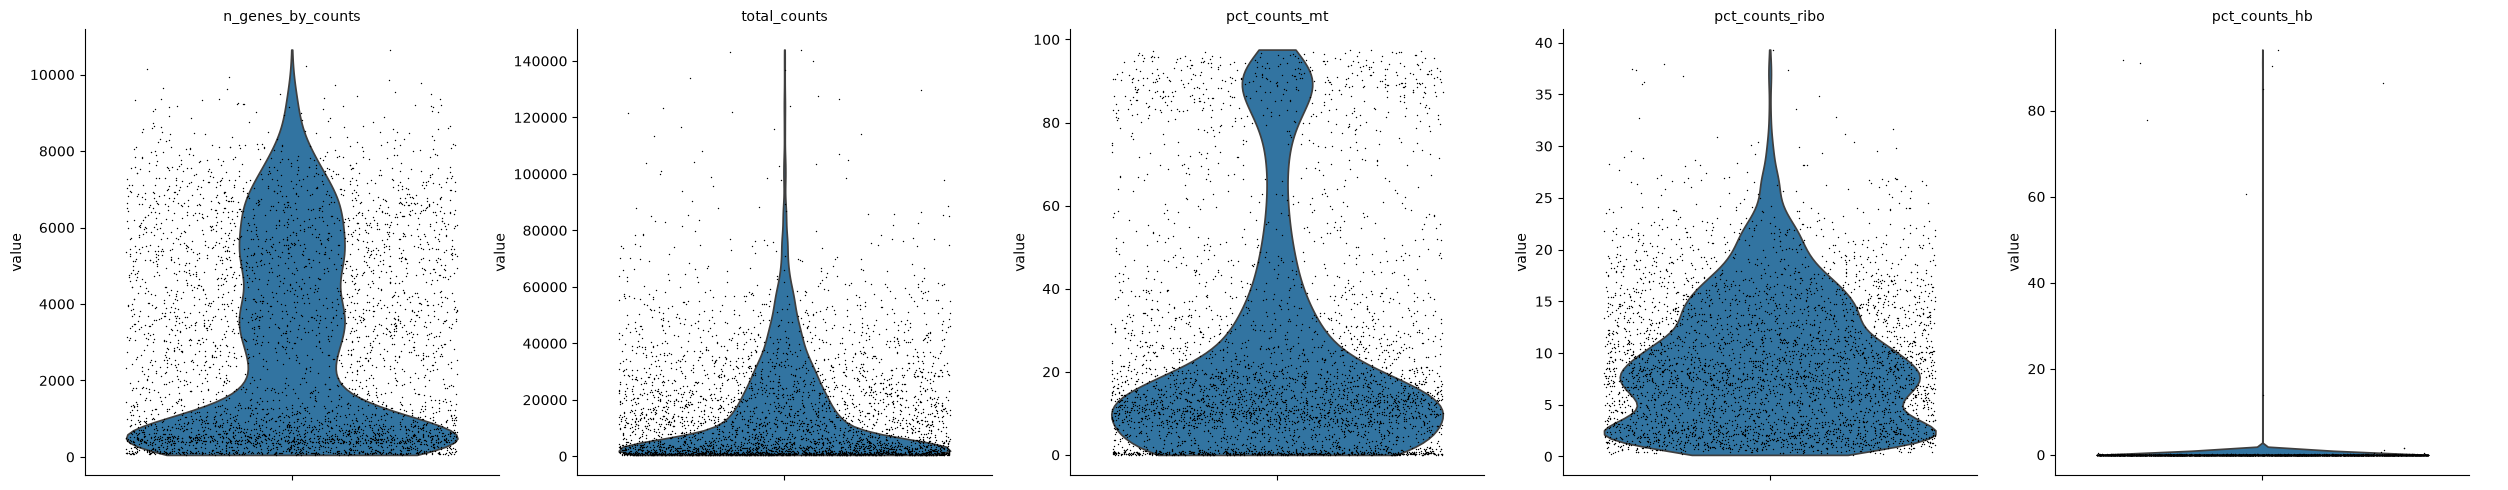

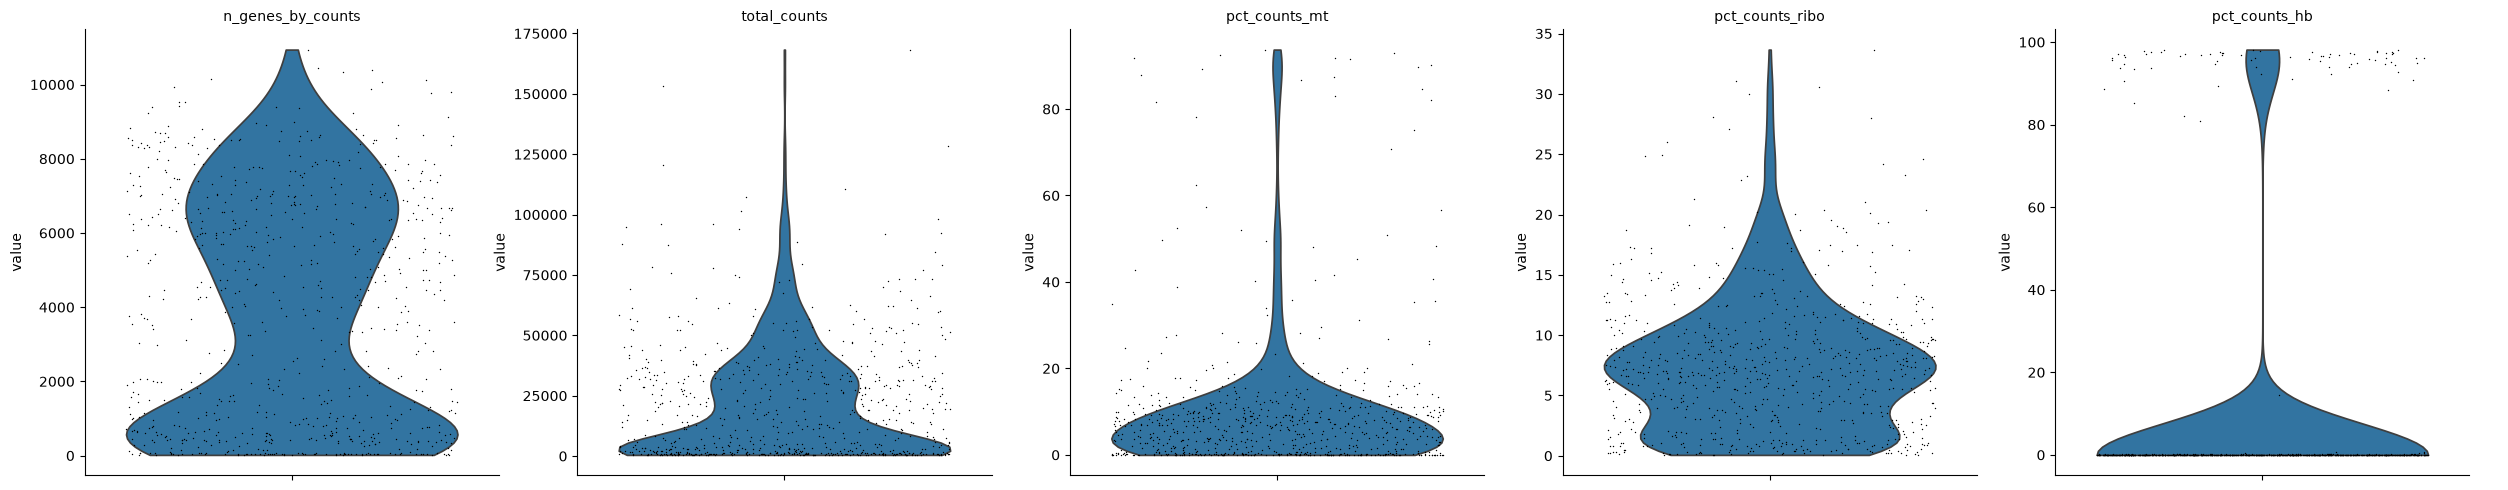

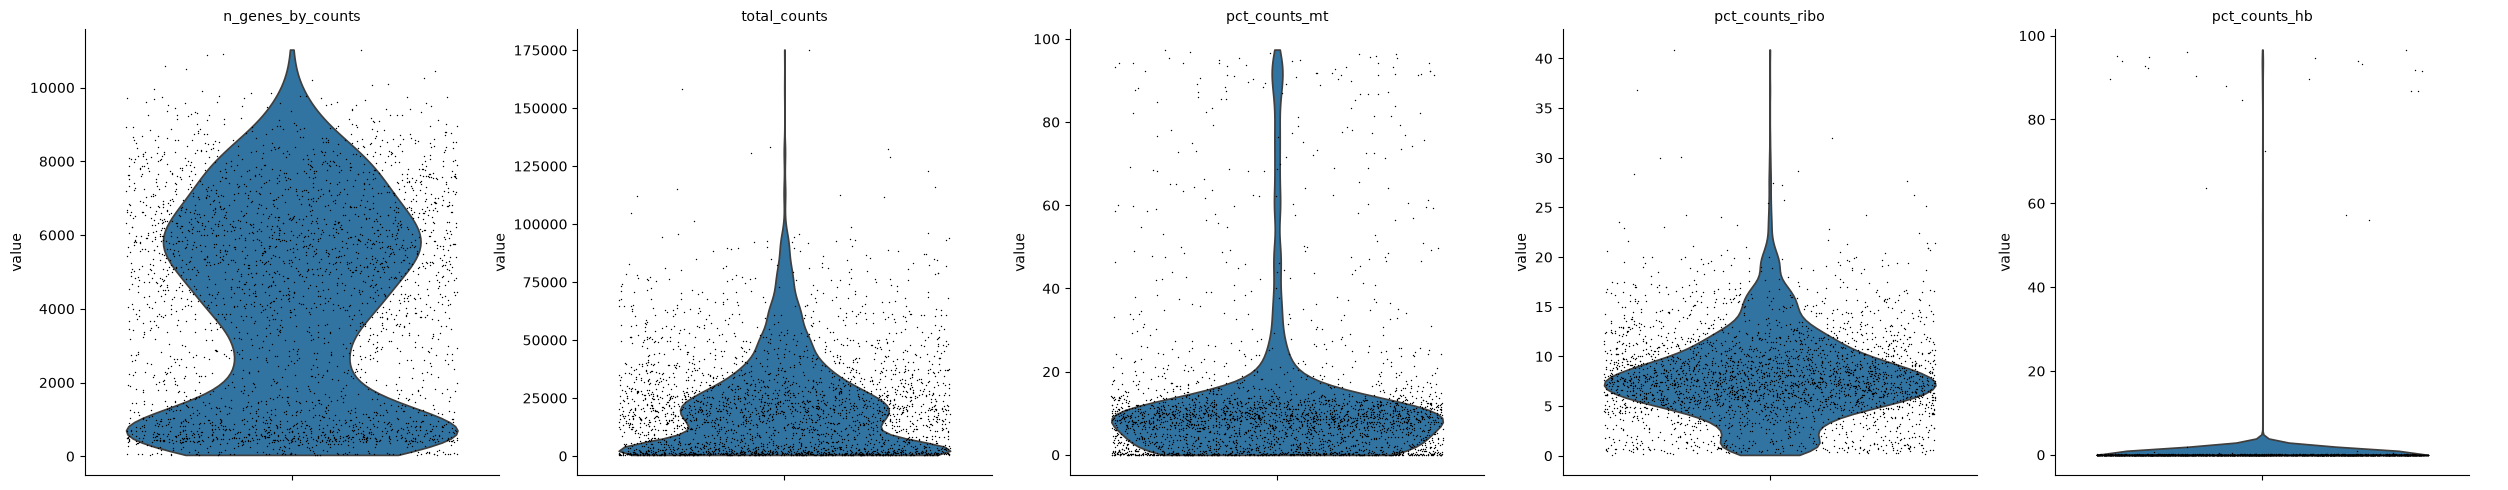

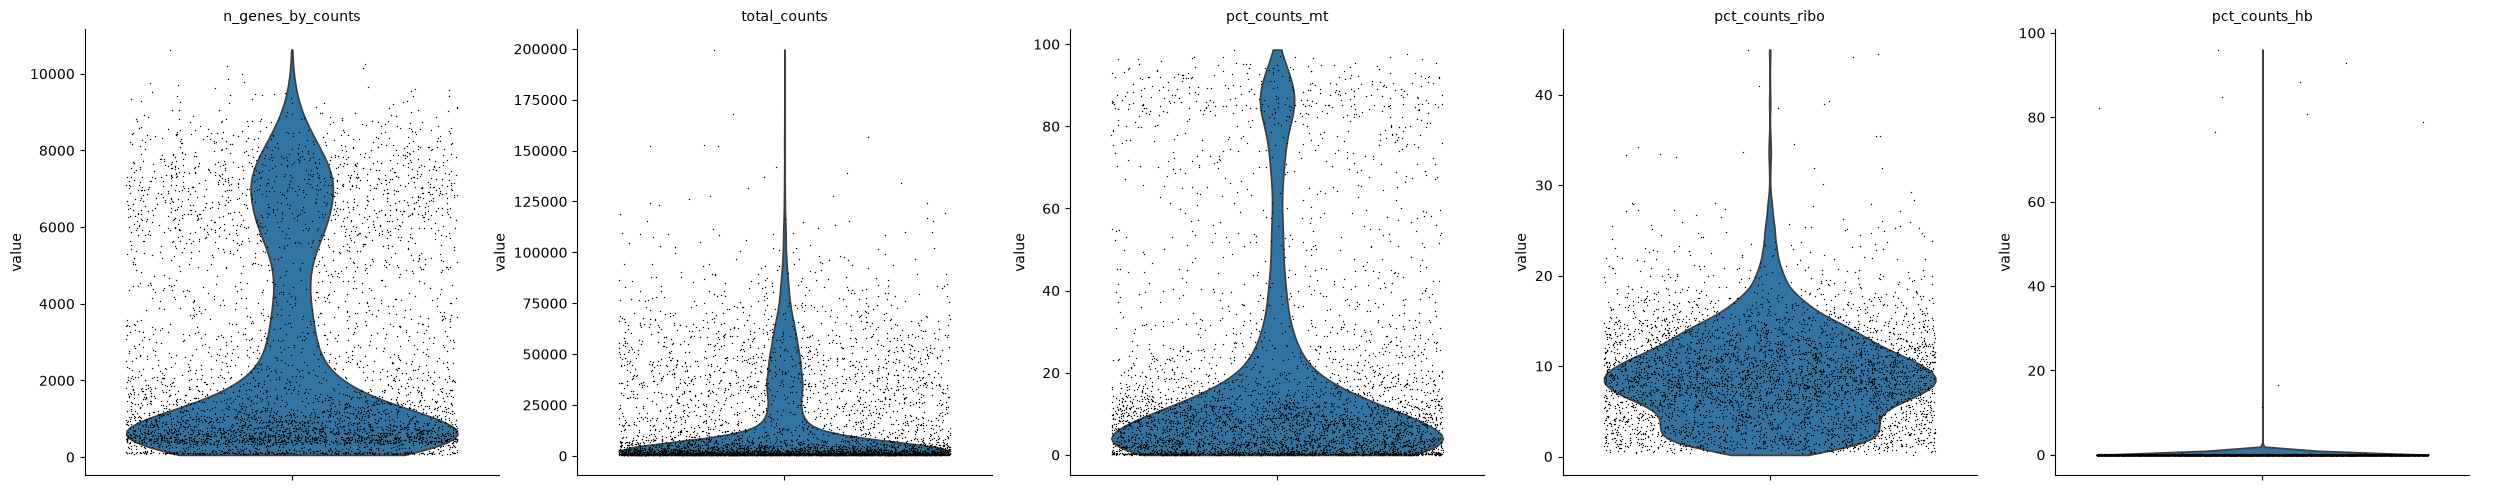

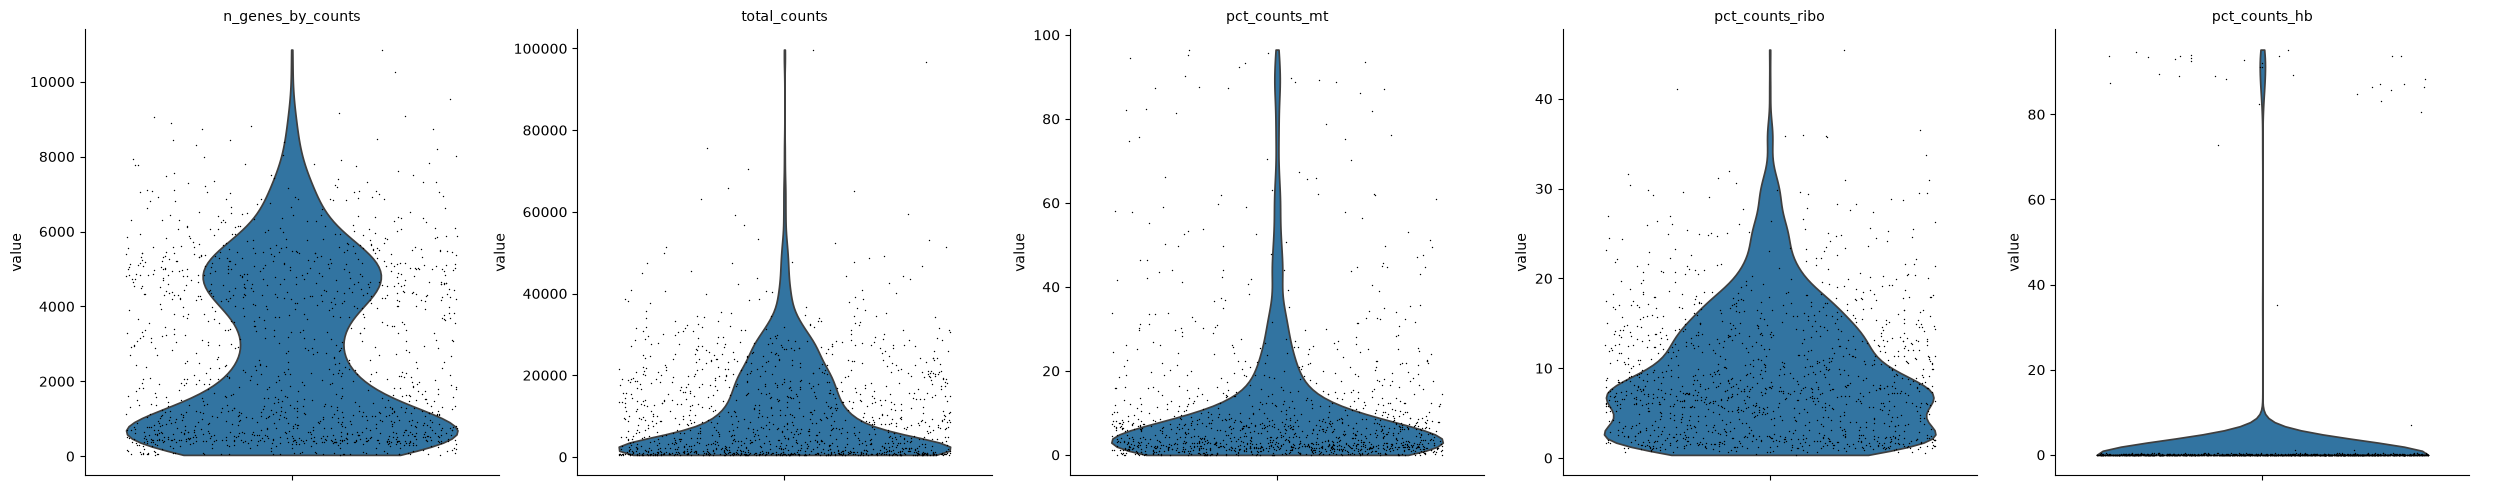

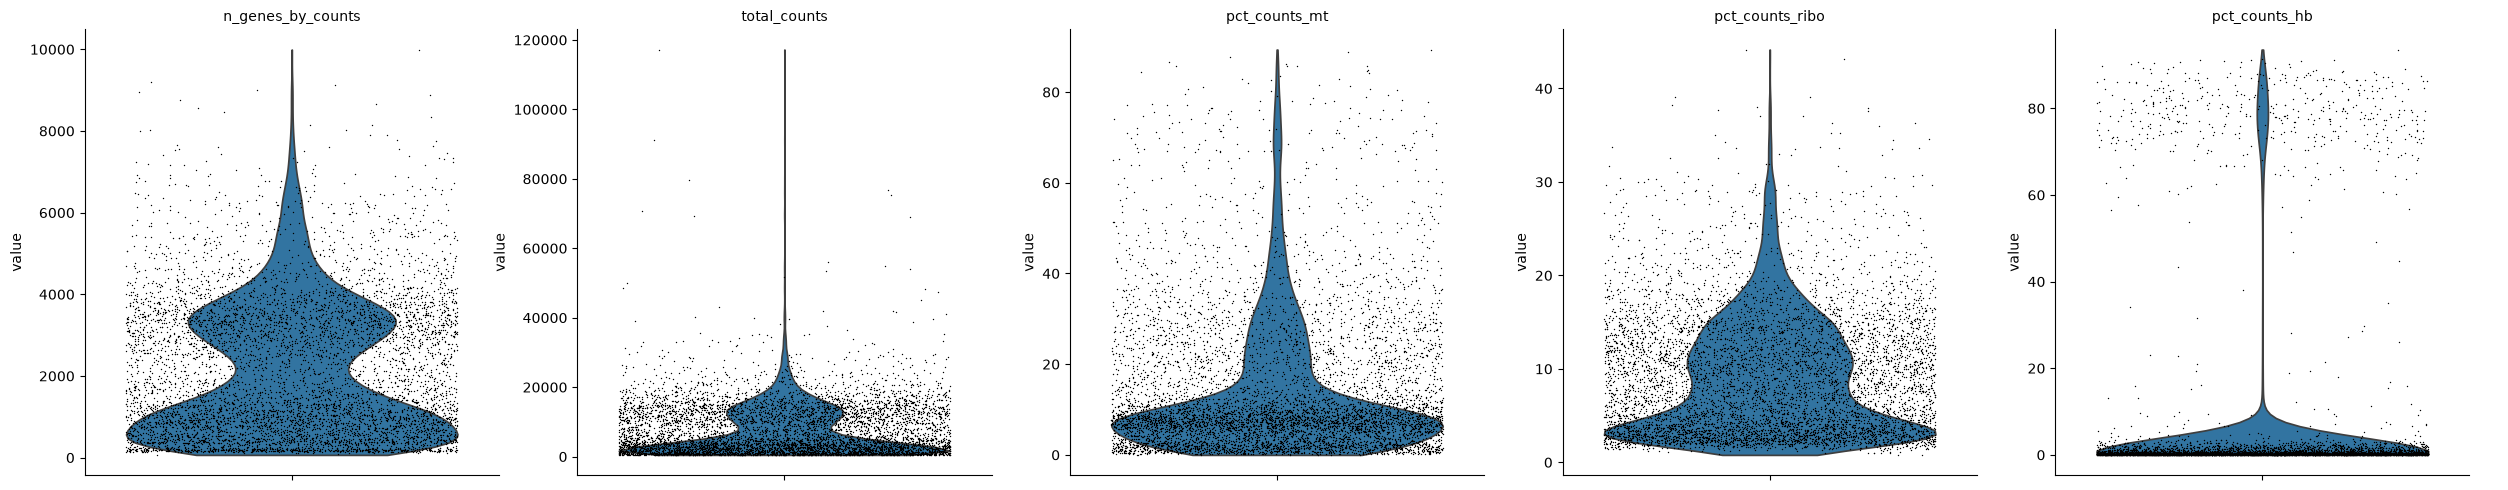

In [5]:
for k, _adata in datasets.items():
    _adata.var["mt"] = _adata.var_names.str.startswith("MT-")
    _adata.var["ribo"] = _adata.var_names.str.startswith(("RPS", "RPL"))
    _adata.var["hb"] = _adata.var_names.str.contains("^HB[^(P)]")
    sc.pp.calculate_qc_metrics(
        _adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
    )
    sc.pl.violin(
        _adata,
        [
            "n_genes_by_counts", "total_counts",
            "pct_counts_mt", "pct_counts_ribo", "pct_counts_hb"
        ],
        jitter=0.4,
        multi_panel=True,
    )
    datasets[k] = _adata[_adata.obs.pct_counts_mt < 25, :].copy()

### 2-2. Doublet Detection

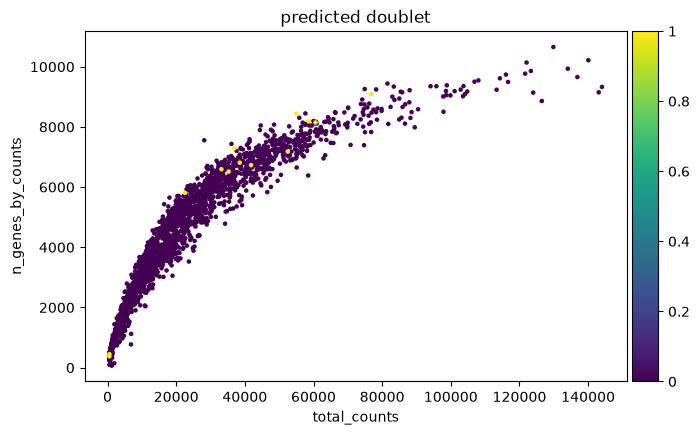

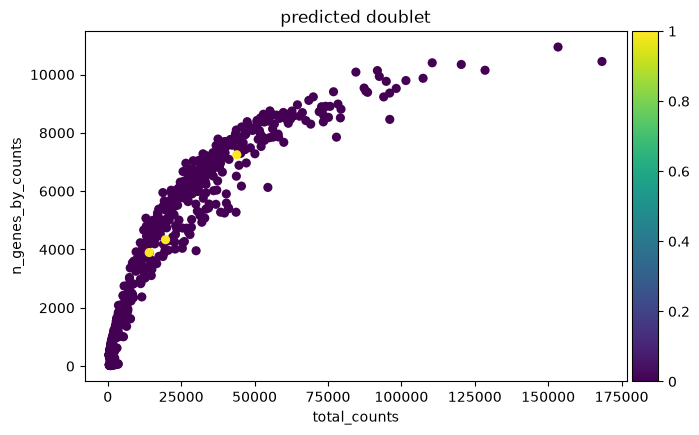

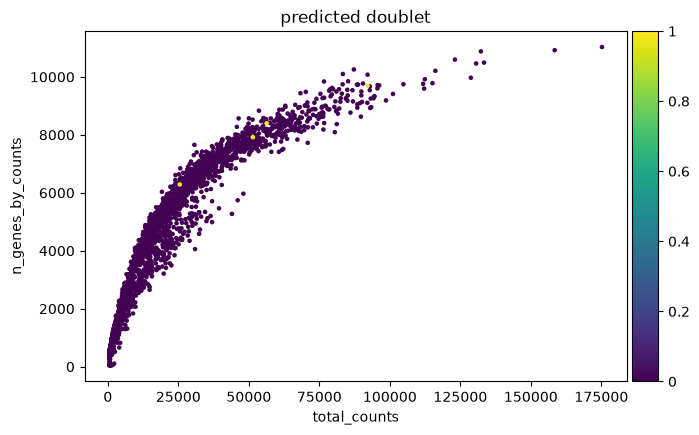

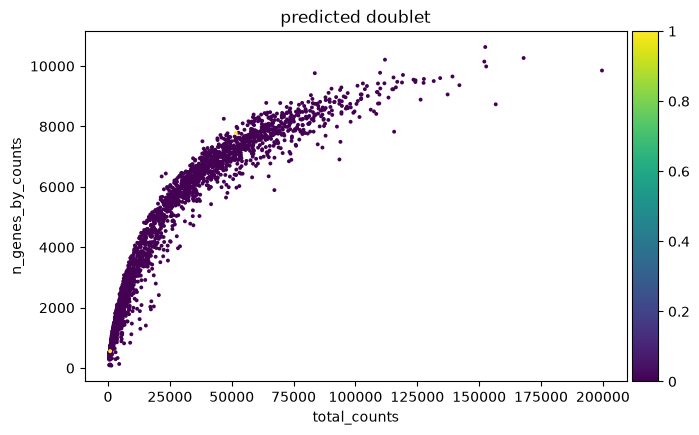

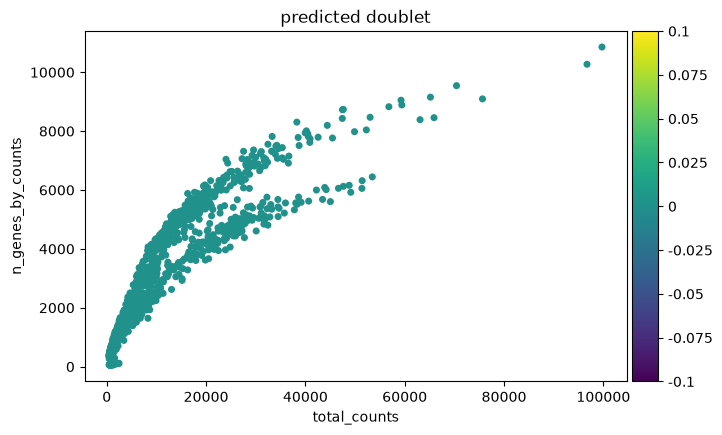

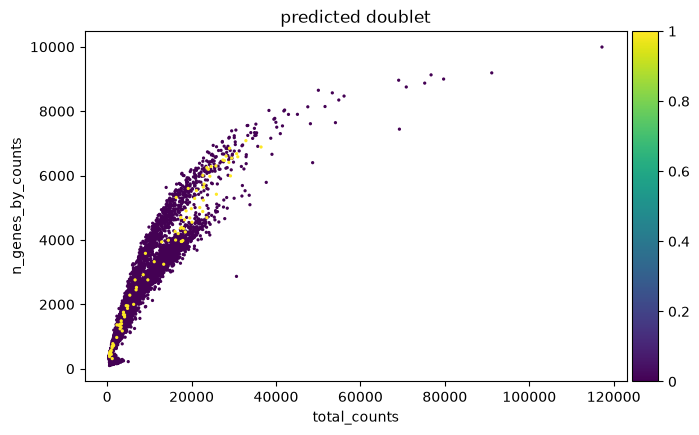

In [6]:
for k, _adata in datasets.items():
    sc.pp.scrublet(_adata)
    sc.pl.scatter(
        _adata, x="total_counts", y="n_genes_by_counts",
        color="predicted_doublet"
    )
    datasets[k] = _adata[~_adata.obs["predicted_doublet"], :].copy()

---
## 3. Normalization and Concatenation

In [7]:
for k, _adata in datasets.items():
    _adata.layers["counts"] = _adata.X.copy()
    sc.pp.normalize_total(_adata, target_sum=1e4)
    sc.pp.log1p(_adata)
    datasets[k] = _adata


adata = ad.concat(datasets, label="batch_id")
adata.obs_names_make_unique()

/tmp/ipykernel_3688458/783649504.py:8: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata = ad.concat(datasets, label="batch_id")


---
## 4. Dimensionality Reduction and Manifold Embedding
### 4-1. Feature Selection

/hshare1/ZETTAI_path_WA_slash_home_KARA/home/yokano/miniforge3/lib/python3.14/functools.py:982: UserWarning: Received a view of an AnnData. Making a copy.
  return dispatch(args[0].__class__)(*args, **kw)


/hshare1/ZETTAI_path_WA_slash_home_KARA/home/yokano/miniforge3/lib/python3.14/functools.py:982: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


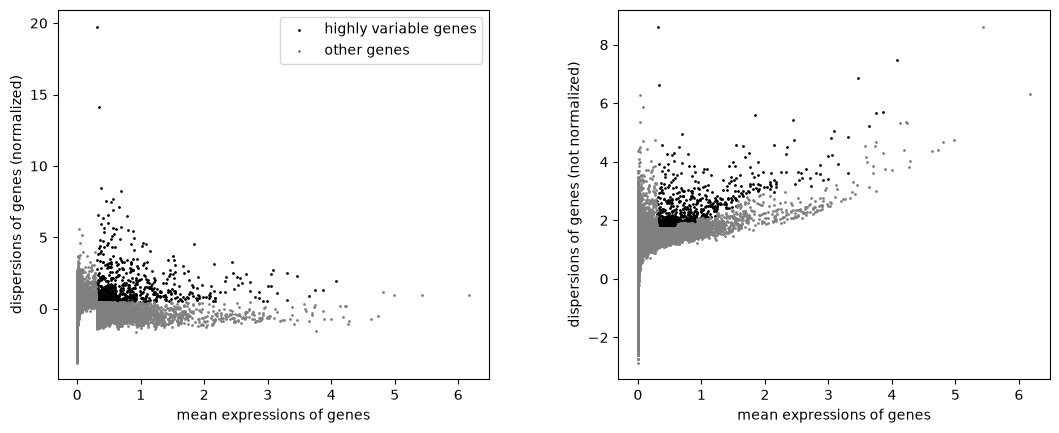

In [8]:
ad_manifold = adata.copy()

sc.pp.highly_variable_genes(
    ad_manifold, min_mean=0.3, max_mean=4.5, min_disp=0.5
)
sc.pl.highly_variable_genes(ad_manifold, show=False)

ad_manifold = ad_manifold[:, ad_manifold.var.highly_variable]
sc.pp.scale(ad_manifold, max_value=10)

### 4-2. Dimensionality Reduction


In [9]:
sc.tl.pca(ad_manifold, svd_solver="arpack")

### 4-3. Manifold Embedding

In [10]:
sc.pp.neighbors(ad_manifold, n_pcs=50)
sc.tl.umap(ad_manifold)

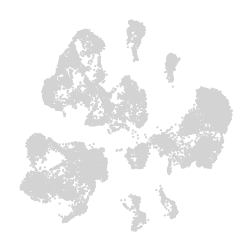

In [11]:

fig, ax = plt.subplots(figsize=(3, 3))

sc.pl.umap(ad_manifold, ax=ax, size=10, show=False)
ax.axis("off");

In [12]:
transfer_embedding_info(adata_source=ad_manifold, adata_target=adata, overwrite=True)
del ad_manifold

---
## 5. Clustering

In [13]:
sc.tl.leiden(adata, resolution=1)

/tmp/ipykernel_3688458/1886685787.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=1)


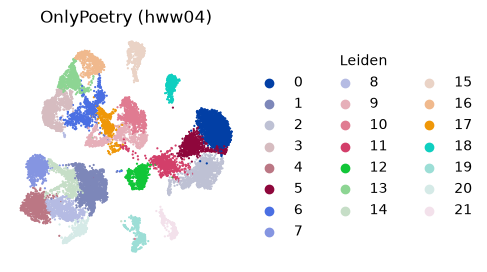

In [14]:
fig, ax = plt.subplots(figsize=(3, 3))

sc.pl.umap(adata, ax=ax, size=10, show=False, color="leiden")
ax.axis("off")
ax.set(title=f"OnlyPoetry ({ENV_SUFFIX})")
ax.legend(
    loc="center left", bbox_to_anchor=(1, 0.5), title="Leiden", frameon=False,
    ncols=math.ceil(adata.obs["leiden"].nunique() / 10)
)

fig.savefig(
    OUTPUT_DIR / f"gbm_umap_{ENV_SUFFIX}.pdf", **kwarg_savefig
)

---
## 6. Execution Environment Details

In [15]:
%%bash
bash .rep_exe_env.sh

Execution Environment

Timestamp (UTC):         2026-09-29T19:28:48Z


Hostname:                hww04


FQDN:                    hww04i


OS:                      Red Hat Enterprise Linux 8.8 (Ootpa)


...

Cores / socket:          24
Threads / core:          1
Logical CPUs:            48


System memory:           1006.9 GiB


System vendor:           XFUSION


System model:            2288H V7


GPU(s):                  None / nvidia-smi unavailable
